# Teacher·Student 성능 평가

Teacher와 Student 5종(1x8, 2x8, 1x16, 2x16, 2x32)의 정확도와 추론시간을 비교


- 대상 서비스: auth, post, comment, frontend
- 기본 측정 조건: CPU, batch=1, PyTorch thread 1개

- Encoder: 입력 장치 이동과 CNN forward 구간
- Detector: Tensor 변환부터 CNN·OCSVM 점수 계산

### 평가 기준

- 정상·공격 모두 세션별로 패킷 5개, stride=1 윈도우
- 점수가 `threshold_df`보다 낮으면 이상으로 판정하고, ROC-AUC는 `-score`로 계산

## 1. 설정과 모델 확인

In [2]:
import gc
import json
import os
import platform
import sys
import time
import warnings
from collections import defaultdict, deque
from pathlib import Path

warnings.filterwarnings("ignore")

import joblib
import numpy as np
import pandas as pd
import sklearn
import torch
from IPython.display import display
from sklearn.metrics import roc_auc_score


# 현재 작업 디렉터리 기준
ROOT = Path.cwd()

PCAP_ROOT = ROOT / "test_pcap_notrecal"

SERVICES = ["auth", "post", "comment", "frontend"]
REMOVED_SERVICES = ["mysql"]

# CPU, batch=1
DEVICE = "cpu"
TORCH_NUM_THREADS = 1
WARMUP_ITERS = 50

ARCH_ORDER = ["1x8", "2x8", "1x16", "2x16", "2x32"]

torch.set_num_threads(TORCH_NUM_THREADS)

# 모델 디렉터리 탐색

found_archs = {
    p.name[len("models_"):]
    for p in ROOT.glob("models_*")
    if p.is_dir()
}
ARCHS = [a for a in ARCH_ORDER if a in found_archs]
ARCHS += sorted(found_archs - set(ARCH_ORDER))

TEACHER_ROOT = ROOT / "teacher_detector"

if not TEACHER_ROOT.is_dir():
    raise FileNotFoundError(
        f"teacher_detector/가 없습니다: {TEACHER_ROOT}\n"
        "Teacher용 OCSVM/threshold 생성 후 다시 실행하세요."
    )

if not ARCHS:
    raise FileNotFoundError(
        f"models_<arch>/ 디렉터리가 없습니다: {ROOT}"
    )

MODEL_SPECS = {
    "teacher": {
        "root": TEACHER_ROOT,
        "encoder": "teacher_ts.pt",
    }
}
for arch in ARCHS:
    MODEL_SPECS[arch] = {
        "root": ROOT / f"models_{arch}",
        "encoder": "student_ts.pt",
    }

MODEL_ORDER = ["teacher"] + ARCHS

# 필수 파일 확인

problems = []

for svc in SERVICES:
    if not (ROOT / svc / f"{svc}_converter.py").is_file():
        problems.append(f"컨버터 없음: {svc}/{svc}_converter.py")

for f in ("converter.py", "converter_common.py"):
    if not (ROOT / f).is_file():
        problems.append(f"공유 모듈 없음: {f}")

for d in ("benign", "attack"):
    if not (PCAP_ROOT / d).is_dir():
        problems.append(f"PCAP 디렉터리 없음: {PCAP_ROOT / d}")

MODEL_STATUS = {}

for model_name, spec in MODEL_SPECS.items():
    MODEL_STATUS[model_name] = {}
    for svc in SERVICES:
        d = spec["root"] / svc

        if not d.is_dir():
            problems.append(f"모델 디렉터리 없음: {d}")
            continue

        enc = d / spec["encoder"]
        if not enc.is_file():
            problems.append(f"인코더 없음: {enc}")

        for fn in ("ocsvm.pkl", "threshold.json"):
            if not (d / fn).is_file():
                problems.append(f"모델 파일 없음: {d / fn}")

        thr_path = d / "threshold.json"
        if thr_path.is_file():
            meta = json.loads(thr_path.read_text(encoding="utf-8"))
            MODEL_STATUS[model_name][svc] = {
                "recalibrated": bool(meta.get("recalibrated")),
                "threshold_df": meta.get("threshold_df"),
                "meta": meta,
            }

if problems:
    raise FileNotFoundError(
        "구조 문제:\n  - " + "\n  - ".join(problems)
    )

print("ROOT       =", ROOT)
print("PCAP_ROOT  =", PCAP_ROOT)
print("MODELS     =", MODEL_ORDER)
print("SERVICES   =", SERVICES)
print("DEVICE     =", DEVICE)
print("torch threads =", torch.get_num_threads())

print("\n[환경]")
print("Python     =", sys.version.split()[0])
print("PyTorch    =", torch.__version__)
print("scikit-learn =", sklearn.__version__)
print("OS         =", platform.platform())
print("Processor  =", platform.processor() or "(unknown)")

print("\n[threshold 상태]")
rows = []
for model_name in MODEL_ORDER:
    for svc in SERVICES:
        st = MODEL_STATUS[model_name][svc]
        rows.append({
            "Model": model_name,
            "Service": svc,
            "Recalibration": "OK" if st["recalibrated"] else "ROLLBK",
            "threshold_df": st["threshold_df"],
        })
display(pd.DataFrame(rows))

from collections import OrderedDict


ROOT       = c:\new_test
PCAP_ROOT  = c:\new_test\test_pcap_notrecal
MODELS     = ['teacher', '1x8', '2x8', '1x16', '2x16', '2x32']
SERVICES   = ['auth', 'post', 'comment', 'frontend']
DEVICE     = cpu
torch threads = 1

[환경]
Python     = 3.12.10
PyTorch    = 2.11.0+cpu
scikit-learn = 1.6.1
OS         = Windows-11-10.0.26200-SP0
Processor  = AMD64 Family 25 Model 68 Stepping 1, AuthenticAMD

[threshold 상태]


,Model,Service,Recalibration,threshold_df
0,teacher,auth,ROLLBK,-54.922443
1,teacher,post,ROLLBK,-21.302479
2,teacher,comment,ROLLBK,-35.801039
3,teacher,frontend,ROLLBK,-162.301080
4,1x8,auth,ROLLBK,-18.319328
5,1x8,post,OK,-29.277913
6,1x8,comment,ROLLBK,-3.732872
7,1x8,frontend,ROLLBK,-0.575867
8,2x8,auth,OK,-3.416311
9,2x8,post,OK,-0.492972


## 2. Converter와 평가 PCAP

In [3]:
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

import converter as _conv_mod
from converter import Converter, read_pcap, WIN_SIZE, FEAT_LEN

print("converter =", _conv_mod.__file__)
print("FEAT_LEN / WIN_SIZE =", FEAT_LEN, "/", WIN_SIZE)

KNOWN_SERVICES = SERVICES + REMOVED_SERVICES

# mysql과 백엔드 d1 제외
EXCLUDED_SERVICES = set(REMOVED_SERVICES)
EXCLUDED_ATTACK_SCENARIOS = {
    ("auth", "d1"),
    ("post", "d1"),
    ("comment", "d1"),
}

EVAL_SCENS = {
    "auth":     ["cred_enum", "k1", "k2"],
    "post":     ["enum_seq", "l3", "l2", "k1", "k2"],
    "comment":  ["enum_seq", "l3", "l2", "k1", "k2"],
    "frontend": ["scan_seq", "r1", "k1", "k2"],
}

SINGLE_PACKET_ATTACK_SCENS = {"k1", "k2"}
EVAL_BENIGN_GAP = WIN_SIZE - 1


def _parse_attack_pcap(path: Path):
    stem = path.stem
    for svc in KNOWN_SERVICES:
        prefix = f"attack_{svc}_"
        if stem.startswith(prefix):
            scen = stem[len(prefix):]
            if scen:
                return svc, scen
    raise ValueError(f"공격 PCAP 이름을 해석할 수 없음: {path.name}")


def _parse_benign_pcap(path: Path):
    stem = path.stem
    for svc in KNOWN_SERVICES:
        if stem == f"benign_{svc}":
            return svc
    raise ValueError(f"benign PCAP 이름을 해석할 수 없음: {path.name}")


attack_paths = sorted((PCAP_ROOT / "attack").glob("*.pcap"))
benign_paths = sorted((PCAP_ROOT / "benign").glob("*.pcap"))

all_attack = [(*_parse_attack_pcap(p), p) for p in attack_paths]
all_benign = [(_parse_benign_pcap(p), p) for p in benign_paths]

EVAL_ATTACK_FILES = []
SKIPPED_ATTACK = []

for svc, scen, p in all_attack:
    if svc in EXCLUDED_SERVICES:
        SKIPPED_ATTACK.append((svc, scen, p, "서비스 제거됨"))
    elif (svc, scen) in EXCLUDED_ATTACK_SCENARIOS:
        SKIPPED_ATTACK.append((svc, scen, p, "탐지 범위 밖(정책)"))
    else:
        EVAL_ATTACK_FILES.append((svc, scen, p))

EVAL_BENIGN_FILES = defaultdict(list)
SKIPPED_BENIGN = []

for svc, p in all_benign:
    if svc in EXCLUDED_SERVICES:
        SKIPPED_BENIGN.append((svc, p, "서비스 제거됨"))
    else:
        EVAL_BENIGN_FILES[svc].append(p)

expected = {
    (svc, scen)
    for svc, scens in EVAL_SCENS.items()
    for scen in scens
    if svc not in EXCLUDED_SERVICES
    and (svc, scen) not in EXCLUDED_ATTACK_SCENARIOS
}
actual = {(svc, scen) for svc, scen, _ in EVAL_ATTACK_FILES}

missing = sorted(expected - actual)
if missing:
    raise FileNotFoundError(
        f"EVAL_SCENS에 정의됐지만 실제 PCAP이 없는 항목: {missing}"
    )

missing_benign = [
    svc for svc in SERVICES
    if not EVAL_BENIGN_FILES.get(svc)
]
if missing_benign:
    raise FileNotFoundError(
        f"benign PCAP이 없는 서비스: {missing_benign}"
    )

all_pcaps = {p.resolve() for p in PCAP_ROOT.rglob("*.pcap")}
recognized = {p.resolve() for _, _, p in all_attack}
recognized |= {p.resolve() for _, p in all_benign}

unhandled = sorted(str(p) for p in all_pcaps - recognized)
if unhandled:
    raise RuntimeError(
        f"이름을 해석할 수 없는 PCAP이 있음: {unhandled}"
    )

print(f"인식한 PCAP = {len(all_pcaps)}개 "
      f"(benign={len(benign_paths)}, attack={len(attack_paths)})")
print(f"혼합 정책 = benign {EVAL_BENIGN_GAP} + attack / "
      f"window={WIN_SIZE}, stride=1")

print("\n[평가 제외]")
for svc, scen, p, why in SKIPPED_ATTACK:
    print(f"  attack {svc}/{scen:10s} {p.name:34s} — {why}")
for svc, p, why in SKIPPED_BENIGN:
    print(f"  benign {svc:17s} {p.name:34s} — {why}")
if not SKIPPED_ATTACK and not SKIPPED_BENIGN:
    print("  (없음)")

print("\n[실제 평가 대상]")
for svc in SERVICES:
    scens = [
        scen for s, scen, _ in EVAL_ATTACK_FILES
        if s == svc
    ]
    print(
        f"  {svc:9s}: benign {len(EVAL_BENIGN_FILES[svc])}개 / "
        f"attack {len(scens)}개 — {', '.join(scens)}"
    )


converter = c:\new_test\converter.py
FEAT_LEN / WIN_SIZE = 20 / 5
인식한 PCAP = 29개 (benign=5, attack=24)
혼합 정책 = benign 4 + attack / window=5, stride=1

[평가 제외]
  attack auth/d1         attack_auth_d1.pcap                — 탐지 범위 밖(정책)
  attack comment/d1         attack_comment_d1.pcap             — 탐지 범위 밖(정책)
  attack mysql/c2         attack_mysql_c2.pcap               — 서비스 제거됨
  attack mysql/e1         attack_mysql_e1.pcap               — 서비스 제거됨
  attack mysql/k1         attack_mysql_k1.pcap               — 서비스 제거됨
  attack mysql/k2         attack_mysql_k2.pcap               — 서비스 제거됨
  attack post/d1         attack_post_d1.pcap                — 탐지 범위 밖(정책)
  benign mysql             benign_mysql.pcap                  — 서비스 제거됨

[실제 평가 대상]
  auth     : benign 1개 / attack 3개 — cred_enum, k1, k2
  post     : benign 1개 / attack 5개 — enum_seq, k1, k2, l2, l3
  comment  : benign 1개 / attack 5개 — enum_seq, k1, k2, l2, l3
  frontend : benign 1개 / attack 4개 — k1, k2, r1, scan_seq


## 3. 평가 이미지 생성

`Converter.extract`로 얻은 벡터를 세션별로 모아 `to_image`에 넘긴다.
이미지 배열의 크기는 `(N, FEAT_LEN, WIN_SIZE)`다. 세션 간 패킷을 섞지 않는다.

In [ ]:
def _scenario_from_attack_source(source_name, svc):
    stem = Path(source_name).stem
    prefix = f"attack_{svc}_"
    return stem[len(prefix):] if stem.startswith(prefix) else stem


def _extract_sessions(svc, pcap_path):
    """변환 가능한 패킷을 도착 순서대로 세션별 벡터로 묶는다."""
    conv = Converter(svc)
    conv.reset()
    packets = read_pcap(str(pcap_path), "auto", limit=None)

    sessions = OrderedDict()
    kept = 0
    for pkt in packets:
        r = conv.extract(pkt)
        if r is None:
            continue
        vec = np.asarray(r[0], dtype=np.float32).copy()
        sessions.setdefault(pkt.session_id, []).append(vec)
        kept += 1

    ordered = list(sessions.items())
    stat = {
        "pcap": pcap_path.name,
        "raw_egress_packets": len(packets),
        "kept_packets": kept,
        "sessions": len(ordered),
    }
    return ordered, stat


def _session_images(svc, sessions):
    """세션별 stride=1 윈도우를 (N, FEAT_LEN, WIN_SIZE) 이미지로 변환한다."""
    image_conv = Converter(svc)
    imgs = []
    for _sid, vecs in sessions:
        if len(vecs) < WIN_SIZE:
            continue
        win = deque(maxlen=WIN_SIZE)
        for v in vecs:
            win.append(v)
            if len(win) == WIN_SIZE:
                imgs.append(
                    np.asarray(image_conv.to_image(list(win)), dtype=np.float32)
                )
    if imgs:
        return np.stack(imgs, axis=0)
    return np.empty((0, FEAT_LEN, WIN_SIZE), dtype=np.float32)


def _count_session_images(sessions):
    return sum(max(0, len(vecs) - WIN_SIZE + 1) for _sid, vecs in sessions)


def build_service_dataset(svc):
    """정상·공격 이미지, 공격 시나리오별 구간과 메타데이터를 반환한다."""
    # 정상 이미지
    benign_sessions = []
    benign_pcap_stats = []
    for bp in EVAL_BENIGN_FILES[svc]:
        sess, stat = _extract_sessions(svc, bp)
        benign_pcap_stats.append(stat)
        benign_sessions.extend(sess)

    X_benign = _session_images(svc, benign_sessions)
    n_benign = len(X_benign)
    if n_benign == 0:
        raise RuntimeError(f"{svc}: pure benign 평가 이미지가 0개")

    # 공격 이미지
    service_attack_files = [
        (scen, ap) for asvc, scen, ap in EVAL_ATTACK_FILES if asvc == svc
    ]

    attack_infos = []
    blocks = []
    scenario_slices = {}
    offset = 0
    total_kept_attack = 0

    for scen, ap in service_attack_files:
        sess, stat = _extract_sessions(svc, ap)
        sess = [(sid, vecs) for sid, vecs in sess if len(vecs) > 0]

        block = _session_images(svc, sess)
        n_images = len(block)

        # 이미지 수 확인
        expected = _count_session_images(sess)
        if n_images != expected:
            raise AssertionError(
                f"{svc}/{scen}: image 수 불일치 actual={n_images}, expected={expected}"
            )

        if n_images == 0:
            # 짧은 세션만 있으면 빈 구간으로 기록
            scenario_slices[scen] = slice(offset, offset)
        else:
            blocks.append(block)
            scenario_slices[scen] = slice(offset, offset + n_images)
            offset += n_images

        kept = sum(len(vecs) for _sid, vecs in sess)
        total_kept_attack += kept
        attack_infos.append({
            "scenario": scen,
            "path": ap,
            "sessions": sess,
            "stat": stat,
            "n_images": n_images,
            "kept_packets": kept,
            "mode": "session-buffer",
        })

    if offset == 0:
        raise RuntimeError(f"{svc}: attack 평가 이미지가 0개")

    X_attack = (
        np.concatenate(blocks, axis=0) if blocks
        else np.empty((0, FEAT_LEN, WIN_SIZE), dtype=np.float32)
    )
    if len(X_attack) != offset:
        raise AssertionError(
            f"{svc}: 전체 attack image 수 불일치 actual={len(X_attack)}, expected={offset}"
        )

    meta = {
        "benign_pcap_stats": benign_pcap_stats,
        "attack_infos": attack_infos,
        "kept_attack_packets": total_kept_attack,
        "n_benign": n_benign,
        "n_attack": offset,
        "image_policy": "session-buffer (runtime ModelConverter parity)",
    }
    return X_benign, X_attack, scenario_slices, meta


In [21]:
# PCAP별 이미지 크기와 세션 수 확인
import gc

benign_rows = []
attack_rows = []

for svc in SERVICES:
    X_benign, X_attack, scenario_slices, meta = build_service_dataset(svc)

    benign_sessions = sum(
        stat["sessions"] for stat in meta["benign_pcap_stats"]
    )
    benign_names = ", ".join(
        stat["pcap"] for stat in meta["benign_pcap_stats"]
    )
    benign_rows.append(
        (svc, benign_names, X_benign.shape, benign_sessions)
    )

    for info in meta["attack_infos"]:
        scen = info["scenario"]
        sl = scenario_slices[scen]
        attack_rows.append(
            (
                info["path"].name,
                X_attack[sl].shape,
                len(info["sessions"]),
            )
        )

    del X_benign, X_attack, scenario_slices, meta
    gc.collect()


print("=== test_pcap_notrecal/benign/ ===")
for svc, pcap_names, shape, n_sessions in benign_rows:
    print(
        f"  {svc:9} {pcap_names:32} "
        f"{str(shape):20} sessions={n_sessions}"
    )

print("\n=== test_pcap_notrecal/attack/ (실제 평가 대상만) ===")
for pcap_name, shape, n_sessions in sorted(attack_rows):
    print(
        f"  {pcap_name:40} "
        f"{str(shape):20} sessions={n_sessions}"
    )

=== test_pcap_notrecal/benign/ ===
  auth      benign_auth.pcap                 (106282, 20, 5)      sessions=888
  post      benign_post.pcap                 (1376, 20, 5)        sessions=9
  comment   benign_comment.pcap              (8358, 20, 5)        sessions=46
  frontend  benign_frontend.pcap             (41724, 20, 5)       sessions=72

=== test_pcap_notrecal/attack/ (실제 평가 대상만) ===
  attack_auth_cred_enum.pcap               (854, 20, 5)         sessions=74
  attack_auth_k1.pcap                      (2142, 20, 5)        sessions=204
  attack_auth_k2.pcap                      (1349, 20, 5)        sessions=141
  attack_comment_enum_seq.pcap             (96, 20, 5)          sessions=1
  attack_comment_k1.pcap                   (1836, 20, 5)        sessions=146
  attack_comment_k2.pcap                   (1120, 20, 5)        sessions=87
  attack_comment_l2.pcap                   (118, 20, 5)         sessions=8
  attack_comment_l3.pcap                   (80, 20, 5)          sessions

## 4. 모델 로드와 성능 측정

- Teacher: `teacher_detector/<svc>/teacher_ts.pt`
- Student: `models_<arch>/<svc>/student_ts.pt`

OCSVM과 임계값은 각 모델의 같은 서비스 폴더에서 읽는다.

In [5]:
def _safe_div(a, b):
    return float(a) / float(b) if b else float("nan")


def metrics_from_scores(
    benign_scores,
    attack_scores,
    threshold,
):
    benign_pred_anom = benign_scores < threshold
    attack_pred_anom = attack_scores < threshold

    FP = int(benign_pred_anom.sum())
    TN = int(len(benign_scores) - FP)
    TP = int(attack_pred_anom.sum())
    FN = int(len(attack_scores) - TP)

    recall = _safe_div(TP, TP + FN)
    fpr = _safe_div(FP, FP + TN)
    precision = _safe_div(TP, TP + FP)
    accuracy = _safe_div(
        TP + TN,
        TP + TN + FP + FN,
    )

    if (
        np.isfinite(precision)
        and np.isfinite(recall)
        and precision + recall > 0
    ):
        f1 = (
            2 * precision * recall
            / (precision + recall)
        )
    else:
        f1 = float("nan")

    if len(benign_scores) and len(attack_scores):
        y_true = np.r_[
            np.zeros(len(benign_scores), dtype=np.int8),
            np.ones(len(attack_scores), dtype=np.int8),
        ]
        # 낮은 점수가 이상이므로 AUC 계산 시 부호 반전
        y_score = np.r_[
            -benign_scores,
            -attack_scores,
        ]
        auc = float(
            roc_auc_score(
                y_true,
                y_score,
            )
        )
    else:
        auc = float("nan")

    return {
        "TP": TP,
        "FP": FP,
        "TN": TN,
        "FN": FN,
        "recall": recall,
        "fpr": fpr,
        "precision": precision,
        "accuracy": accuracy,
        "f1": f1,
        "auc": auc,
    }


class EvalDetector:
    """정확도 평가와 Encoder·Detector 시간 측정용 클래스."""

    def __init__(
        self,
        model_name: str,
        service: str,
        device: str = "cpu",
    ):
        spec = MODEL_SPECS[model_name]
        svc_dir = Path(spec["root"]) / service

        self.model_name = model_name
        self.service = service
        self.device = device

        self.encoder_path = (
            svc_dir / spec["encoder"]
        )
        self.encoder = torch.jit.load(
            str(self.encoder_path),
            map_location=device,
        ).eval()

        self.ocsvm = joblib.load(
            svc_dir / "ocsvm.pkl"
        )

        with open(
            svc_dir / "threshold.json",
            encoding="utf-8",
        ) as f:
            self.meta = json.load(f)

        self.threshold = float(
            self.meta["threshold_df"]
        )
        self.recalibrated = bool(
            self.meta.get("recalibrated")
        )

        self.params = int(
            sum(
                p.numel()
                for p in self.encoder.parameters()
            )
        )

        self.reset_timing()

    def reset_timing(self):
        self.n_scored = 0
        self.encoder_ns = 0
        self.detector_ns = 0

    def _score_one(self, image, measure=True):
        # Tensor 변환부터 OCSVM 점수 계산까지 측정
        t0 = time.perf_counter_ns()

        x = torch.from_numpy(
            np.ascontiguousarray(
                image,
                dtype=np.float32,
            )
        )[None, None]

        t1 = time.perf_counter_ns()

        with torch.inference_mode():
            emb = self.encoder(
                x.to(self.device)
            )

        t2 = time.perf_counter_ns()

        emb_np = emb.detach().cpu().numpy()
        score = float(
            self.ocsvm.decision_function(
                emb_np
            )[0]
        )

        t3 = time.perf_counter_ns()

        if measure:
            self.n_scored += 1
            self.encoder_ns += (
                t2 - t1
            )
            self.detector_ns += (
                t3 - t0
            )

        return score

    def warmup(self, image, n=WARMUP_ITERS):
        for _ in range(n):
            self._score_one(
                image,
                measure=False,
            )

    def score_many(self, images):
        scores = np.empty(
            len(images),
            dtype=np.float64,
        )

        for i in range(len(images)):
            scores[i] = self._score_one(
                images[i],
                measure=True,
            )

        return scores

    def timing(self):
        if self.n_scored == 0:
            return {
                "images": 0,
                "encoder_total_s": 0.0,
                "detector_total_s": 0.0,
                "encoder_ms_per_img": float("nan"),
                "detector_ms_per_img": float("nan"),
            }

        enc_s = self.encoder_ns / 1e9
        det_s = self.detector_ns / 1e9

        return {
            "images": self.n_scored,
            "encoder_total_s": enc_s,
            "detector_total_s": det_s,
            "encoder_ms_per_img":
                enc_s * 1000 / self.n_scored,
            "detector_ms_per_img":
                det_s * 1000 / self.n_scored,
        }


## 5. 전체 평가

서비스별 이미지를 한 번 만들어 모든 모델에 재사용한다. 평가가 끝난 서비스의 배열은 메모리에서 해제한다.

In [6]:
SERVICE_ROWS = []
SCENARIO_ROWS = []

for svc in SERVICES:
    print("\n" + "=" * 120)
    print(f"■ SERVICE: {svc}")
    print("=" * 120)

    # 이미지 생성 시간은 추론시간에서 제외
    prep_t0 = time.perf_counter()

    (
        X_benign,
        X_attack,
        scenario_slices,
        data_meta,
    ) = build_service_dataset(svc)

    prep_s = time.perf_counter() - prep_t0

    mem_mb = (
        X_benign.nbytes
        + X_attack.nbytes
    ) / (1024 ** 2)

    print(
        f"images: benign={len(X_benign):,}, "
        f"attack={len(X_attack):,}, "
        f"total={len(X_benign)+len(X_attack):,}"
    )
    print(
        f"image cache={mem_mb:.1f} MiB, "
        f"preprocessing={prep_s:.2f}s "
        "(latency에서 제외)"
    )

    print("\n[attack scenario images]")
    for scen, sl in scenario_slices.items():
        print(
            f"  {scen:16s}: "
            f"{sl.stop - sl.start:,}"
        )

    first_image = (
        X_benign[0]
        if len(X_benign)
        else X_attack[0]
    )

    # 모든 모델에 같은 이미지 사용
    for model_name in MODEL_ORDER:
        print(
            f"\n  [{model_name}] loading / warm-up..."
        )

        det = EvalDetector(
            model_name,
            svc,
            device=DEVICE,
        )

        det.warmup(
            first_image,
            WARMUP_ITERS,
        )
        det.reset_timing()

        benign_scores = det.score_many(
            X_benign
        )
        attack_scores = det.score_many(
            X_attack
        )

        timing = det.timing()

        if timing["images"] != (
            len(X_benign)
            + len(X_attack)
        ):
            raise AssertionError(
                f"{model_name}/{svc}: timing image count 불일치"
            )

        m = metrics_from_scores(
            benign_scores,
            attack_scores,
            det.threshold,
        )

        # 정상 이미지 전체와 해당 시나리오 공격으로 지표 계산
        for scen, sl in scenario_slices.items():
            ss = attack_scores[sl]
            m_s = metrics_from_scores(benign_scores, ss, det.threshold)
            SCENARIO_ROWS.append({
                "Model": model_name,
                "Service": svc,
                "Scenario": scen,
                "Attack Images": len(ss),
                "Benign Images": len(benign_scores),
                "TP": m_s["TP"], "FP": m_s["FP"],
                "TN": m_s["TN"], "FN": m_s["FN"],
                "Accuracy": m_s["accuracy"],
                "Precision": m_s["precision"],
                "Recall": m_s["recall"],
                "FPR": m_s["fpr"],
                "Accuracy (%)": m_s["accuracy"] * 100,
                "Precision (%)": m_s["precision"] * 100,
                "Recall (%)": m_s["recall"] * 100,
                "FPR (%)": m_s["fpr"] * 100,
            })

        status = (
            "OK"
            if det.recalibrated
            else "ROLLBK"
        )

        SERVICE_ROWS.append({
            "Model": model_name,
            "Service": svc,
            "Recalibration": status,
            "Params": det.params,
            "Params (K)": det.params / 1000.0,

            "Benign Images": len(benign_scores),
            "Attack Images": len(attack_scores),
            "Images": timing["images"],

            "TP": m["TP"],
            "FP": m["FP"],
            "TN": m["TN"],
            "FN": m["FN"],

            "Accuracy": m["accuracy"],
            "Precision": m["precision"],
            "Recall": m["recall"],
            "FPR": m["fpr"],
            "F1": m["f1"],
            "ROC-AUC": m["auc"],

            "Accuracy (%)": m["accuracy"] * 100,
            "Precision (%)": m["precision"] * 100,
            "Recall (%)": m["recall"] * 100,
            "FPR (%)": m["fpr"] * 100,

            "Encoder Total (s)":
                timing["encoder_total_s"],
            "Detector Total (s)":
                timing["detector_total_s"],
            "Encoder ms/img":
                timing["encoder_ms_per_img"],
            "Detector ms/img":
                timing["detector_ms_per_img"],

            "threshold_df": det.threshold,
        })

        print(
            f"  [{model_name:7s}] "
            f"{status:6s} | "
            f"Acc={m['accuracy']*100:6.2f}% "
            f"Prec={m['precision']*100:6.2f}% "
            f"Rec={m['recall']*100:6.2f}% "
            f"FPR={m['fpr']*100:6.2f}% "
            f"AUC={m['auc']:.4f} | "
            f"Detector={timing['detector_total_s']:.3f}s "
            f"({timing['detector_ms_per_img']:.4f} ms/img)"
        )

        del det, benign_scores, attack_scores
        gc.collect()

    del X_benign, X_attack
    gc.collect()

print("\n평가 완료")



■ SERVICE: auth
images: benign=106,282, attack=4,345, total=110,627
image cache=42.2 MiB, preprocessing=2.43s (latency에서 제외)

[attack scenario images]
  cred_enum       : 854
  k1              : 2,142
  k2              : 1,349

  [teacher] loading / warm-up...
  [teacher] ROLLBK | Acc= 98.47% Prec= 81.52% Rec= 78.80% FPR=  0.73% AUC=0.9582 | Detector=75.760s (0.6848 ms/img)

  [1x8] loading / warm-up...
  [1x8    ] ROLLBK | Acc= 95.92% Prec=  3.30% Rec=  0.14% FPR=  0.17% AUC=0.5094 | Detector=54.149s (0.4895 ms/img)

  [2x8] loading / warm-up...
  [2x8    ] OK     | Acc= 99.09% Prec= 90.01% Rec= 86.49% FPR=  0.39% AUC=0.9402 | Detector=54.999s (0.4972 ms/img)

  [1x16] loading / warm-up...
  [1x16   ] OK     | Acc= 99.17% Prec= 91.63% Rec= 86.67% FPR=  0.32% AUC=0.9119 | Detector=42.382s (0.3831 ms/img)

  [2x16] loading / warm-up...
  [2x16   ] OK     | Acc= 99.10% Prec= 90.94% Rec= 85.68% FPR=  0.35% AUC=0.9560 | Detector=48.760s (0.4408 ms/img)

  [2x32] loading / warm-up...
  [2x

## 5b. 이미지 생성 확인

서비스별 첫 공격 PCAP에서 세션별 생성과 패킷 순서대로 생성한 이미지 수, 일부 픽셀 값을 비교한다.

In [7]:
def _runtime_images_via_push(svc, pcap_path):
    """패킷 도착 순서대로 세션 버퍼를 갱신하며 이미지를 만든다."""
    conv = Converter(svc); conv.reset()
    windows = OrderedDict()
    packets = read_pcap(str(pcap_path), "auto", limit=None)
    out = []
    for pkt in packets:
        r = conv.extract(pkt)
        if r is None:
            continue
        w = windows.setdefault(pkt.session_id, deque(maxlen=WIN_SIZE))
        w.append(np.asarray(r[0], dtype=np.float32))
        if len(w) == WIN_SIZE:
            out.append(np.asarray(conv.to_image(list(w)), dtype=np.float32))
    return out

_parity_ok = True
for svc in SERVICES:
    # 서비스별 첫 공격 PCAP 비교
    aps = [ap for asvc, scen, ap in EVAL_ATTACK_FILES if asvc == svc]
    if not aps:
        continue
    ap = aps[0]
    sess, _ = _extract_sessions(svc, ap)
    via_build = _session_images(svc, [(s, v) for s, v in sess if len(v) > 0])
    via_push = _runtime_images_via_push(svc, ap)
    same_n = (len(via_build) == len(via_push))
    same_px = same_n and all(
        np.allclose(via_build[i], via_push[i], atol=1e-6)
        for i in range(0, len(via_build), max(1, len(via_build)//50 or 1))
    )
    flag = "OK" if (same_n and same_px) else "MISMATCH"
    if not (same_n and same_px):
        _parity_ok = False
    print(f"  {svc:9s} {ap.name:28s} build={len(via_build):,} push={len(via_push):,} -> {flag}")

print("\n세션-버퍼 정합성:", "전부 일치" if _parity_ok else "불일치 있음 — 확인 필요")


  auth      attack_auth_cred_enum.pcap   build=854 push=854 -> MISMATCH
  post      attack_post_enum_seq.pcap    build=60 push=60 -> OK
  comment   attack_comment_enum_seq.pcap build=96 push=96 -> OK
  frontend  attack_frontend_k1.pcap      build=1,816 push=1,816 -> OK

세션-버퍼 정합성: 불일치 있음 — 확인 필요


## 6. 서비스별 정확도와 추론시간

In [8]:
service_df = pd.DataFrame(SERVICE_ROWS)

service_df["Model"] = pd.Categorical(
    service_df["Model"],
    categories=MODEL_ORDER,
    ordered=True,
)
service_df["Service"] = pd.Categorical(
    service_df["Service"],
    categories=SERVICES,
    ordered=True,
)
service_df = (
    service_df
    .sort_values(["Service", "Model"])
    .reset_index(drop=True)
)

service_view = service_df[[
    "Service",
    "Model",
    "Recalibration",
    "Params (K)",
    "Images",
    "TP", "FP", "TN", "FN",
    "Accuracy (%)",
    "Precision (%)",
    "Recall (%)",
    "FPR (%)",
    "F1",
    "ROC-AUC",
    "Encoder Total (s)",
    "Encoder ms/img",
    "Detector ms/img",
]].copy()

display(
    service_view.style.format({
        "Params (K)": "{:.2f}",
        "Accuracy (%)": "{:.2f}",
        "Precision (%)": "{:.2f}",
        "Recall (%)": "{:.2f}",
        "FPR (%)": "{:.2f}",
        "F1": "{:.4f}",
        "ROC-AUC": "{:.4f}",
        "Encoder Total (s)": "{:.4f}",
        "Encoder ms/img": "{:.6f}",
        "Detector ms/img": "{:.6f}",
    })
)


,Service,Model,Recalibration,Params (K),Images,TP,FP,TN,FN,Accuracy (%),Precision (%),Recall (%),FPR (%),F1,ROC-AUC,Encoder Total (s),Encoder ms/img,Detector ms/img
0,auth,teacher,ROLLBK,314.69,110627,3424,776,105506,921,98.47,81.52,78.80,0.73,0.8014,0.9582,31.3769,0.283628,0.684825
1,auth,1x8,ROLLBK,1.23,110627,6,176,106106,4339,95.92,3.30,0.14,0.17,0.0027,0.5094,11.4194,0.103225,0.489476
2,auth,2x8,OK,5.69,110627,3758,417,105865,587,99.09,90.01,86.49,0.39,0.8822,0.9402,16.3818,0.148081,0.497153
3,auth,1x16,OK,12.64,110627,3766,344,105938,579,99.17,91.63,86.67,0.32,0.8908,0.9119,10.8432,0.098016,0.383111
4,auth,2x16,OK,13.87,110627,3723,371,105911,622,99.10,90.94,85.68,0.35,0.8823,0.9560,17.5018,0.158206,0.440765
5,auth,2x32,OK,87.26,110627,3770,434,105848,575,99.09,89.68,86.77,0.41,0.8820,0.9523,21.9179,0.198124,0.505489
6,post,teacher,ROLLBK,314.69,4553,3059,152,1224,118,94.07,95.27,96.29,11.05,0.9577,0.9718,1.2512,0.274806,0.670649
7,post,1x8,OK,1.23,4553,3059,0,1376,118,97.41,100.00,96.29,0.00,0.9811,0.9985,0.4552,0.099987,0.361527
8,post,2x8,OK,5.69,4553,3059,5,1371,118,97.30,99.84,96.29,0.36,0.9803,0.9876,0.7100,0.155935,0.611189
9,post,1x16,OK,12.64,4553,3059,0,1376,118,97.41,100.00,96.29,0.00,0.9811,0.9926,0.4327,0.095044,0.364189


## 7. 모델별 요약

Precision, Recall, Accuracy는 4개 서비스의 TP/FP/TN/FN을 합쳐 계산한다.
서비스마다 점수 범위가 달라 ROC-AUC는 서비스별 평균과 최솟값으로 비교한다.

`Total Inference (s)`는 서비스별 Detector 시간의 합계이며, `Inference ms/img`는 전체 이미지당 평균이다.

In [9]:
summary_rows = []

for model_name in MODEL_ORDER:
    g = service_df[
        service_df["Model"].astype(str)
        == model_name
    ]

    TP = int(g["TP"].sum())
    FP = int(g["FP"].sum())
    TN = int(g["TN"].sum())
    FN = int(g["FN"].sum())

    precision = _safe_div(
        TP,
        TP + FP,
    )
    recall = _safe_div(
        TP,
        TP + FN,
    )
    accuracy = _safe_div(
        TP + TN,
        TP + TN + FP + FN,
    )
    fpr = _safe_div(
        FP,
        FP + TN,
    )

    if (
        np.isfinite(precision)
        and np.isfinite(recall)
        and precision + recall > 0
    ):
        f1 = (
            2 * precision * recall
            / (precision + recall)
        )
    else:
        f1 = float("nan")

    total_images = int(
        g["Images"].sum()
    )
    encoder_total = float(
        g["Encoder Total (s)"].sum()
    )
    detector_total = float(
        g["Detector Total (s)"].sum()
    )

    # 같은 아키텍처의 파라미터 수 확인
    params_unique = sorted(
        set(
            int(x)
            for x in g["Params"].tolist()
        )
    )

    if len(params_unique) != 1:
        print(
            f"⚠️ {model_name}: 서비스별 Params가 다름: "
            f"{params_unique}"
        )

    params = max(params_unique)

    summary_rows.append({
        "Model": model_name,
        "Recalibration OK":
            f"{int((g['Recalibration'] == 'OK').sum())}/{len(SERVICES)}",
        "Params": params,
        "Params (K)": params / 1000.0,
        "Images": total_images,

        "TP": TP,
        "FP": FP,
        "TN": TN,
        "FN": FN,

        "Accuracy (%)": accuracy * 100,
        "Precision (%)": precision * 100,
        "Recall (%)": recall * 100,
        "FPR (%)": fpr * 100,
        "F1": f1,

        "Mean ROC-AUC":
            float(g["ROC-AUC"].mean()),
        "Worst ROC-AUC":
            float(g["ROC-AUC"].min()),

        "Encoder Total (s)": encoder_total,
        "Total Inference (s)": detector_total,

        "Encoder ms/img":
            encoder_total * 1000 / total_images,
        "Inference ms/img":
            detector_total * 1000 / total_images,
    })

summary_df = pd.DataFrame(
    summary_rows
)

teacher_ms = float(
    summary_df.loc[
        summary_df["Model"] == "teacher",
        "Inference ms/img",
    ].iloc[0]
)

summary_df["Latency reduction vs Teacher (%)"] = (
    100
    * (
        1
        - summary_df["Inference ms/img"]
        / teacher_ms
    )
)

summary_df.loc[
    summary_df["Model"] == "teacher",
    "Latency reduction vs Teacher (%)"
] = 0.0

summary_view = summary_df[[
    "Model",
    "Recalibration OK",
    "Params (K)",
    "Accuracy (%)",
    "Precision (%)",
    "Recall (%)",
    "FPR (%)",
    "F1",
    "Mean ROC-AUC",
    "Worst ROC-AUC",
    "Inference ms/img",
    "Encoder Total (s)",
    "Encoder ms/img",
    "Latency reduction vs Teacher (%)",
]].copy()

display(
    summary_view.style.format({
        "Params (K)": "{:.2f}",
        "Accuracy (%)": "{:.2f}",
        "Precision (%)": "{:.2f}",
        "Recall (%)": "{:.2f}",
        "FPR (%)": "{:.2f}",
        "F1": "{:.4f}",
        "Mean ROC-AUC": "{:.4f}",
        "Worst ROC-AUC": "{:.4f}",
        "Inference ms/img": "{:.6f}",
        "Encoder Total (s)": "{:.4f}",
        "Encoder ms/img": "{:.6f}",
        "Latency reduction vs Teacher (%)": "{:.2f}",
    })
)


,Model,Recalibration OK,Params (K),Accuracy (%),Precision (%),Recall (%),FPR (%),F1,Mean ROC-AUC,Worst ROC-AUC,Inference ms/img,Encoder Total (s),Encoder ms/img,Latency reduction vs Teacher (%)
0,teacher,0/4,314.69,98.22,98.79,97.31,1.02,0.9804,0.9748,0.9582,0.700291,85.5184,0.292985,0.00
1,1x8,1/4,1.23,97.60,99.58,95.18,0.34,0.9733,0.8689,0.5094,0.633307,39.1353,0.134077,9.57
2,2x8,3/4,5.69,99.39,99.31,99.36,0.58,0.9934,0.9773,0.9402,0.698127,56.0329,0.191968,0.31
3,1x16,2/4,12.64,64.51,97.75,23.31,0.46,0.3764,0.9100,0.7581,0.480664,31.0472,0.106367,31.36
4,2x16,3/4,13.87,99.36,99.27,99.34,0.62,0.9930,0.9808,0.9560,0.562640,50.5743,0.173267,19.66
5,2x32,2/4,87.26,99.36,99.42,99.20,0.50,0.9931,0.9775,0.9523,0.706554,71.9650,0.246551,-0.89


### 주요 지표

In [10]:
compact_df = summary_df[[
    "Model",
    "Params (K)",
    "Precision (%)",
    "Recall (%)",
    "Accuracy (%)",
    "Mean ROC-AUC",
    "Worst ROC-AUC",
    "Inference ms/img",
    "Encoder ms/img",
    "Latency reduction vs Teacher (%)",
]].copy()

display(
    compact_df.style.format({
        "Params (K)": "{:.2f}",
        "Precision (%)": "{:.2f}",
        "Recall (%)": "{:.2f}",
        "Accuracy (%)": "{:.2f}",
        "Mean ROC-AUC": "{:.4f}",
        "Worst ROC-AUC": "{:.4f}",
        "Inference ms/img": "{:.6f}",
        "Encoder ms/img": "{:.6f}",
        "Latency reduction vs Teacher (%)": "{:.2f}",
    })
)


,Model,Params (K),Precision (%),Recall (%),Accuracy (%),Mean ROC-AUC,Worst ROC-AUC,Inference ms/img,Encoder ms/img,Latency reduction vs Teacher (%)
0,teacher,314.69,98.79,97.31,98.22,0.9748,0.9582,0.700291,0.292985,0.00
1,1x8,1.23,99.58,95.18,97.60,0.8689,0.5094,0.633307,0.134077,9.57
2,2x8,5.69,99.31,99.36,99.39,0.9773,0.9402,0.698127,0.191968,0.31
3,1x16,12.64,97.75,23.31,64.51,0.9100,0.7581,0.480664,0.106367,31.36
4,2x16,13.87,99.27,99.34,99.36,0.9808,0.9560,0.562640,0.173267,19.66
5,2x32,87.26,99.42,99.20,99.36,0.9775,0.9523,0.706554,0.246551,-0.89


## 8. 시나리오별 지표

In [11]:
scenario_df = pd.DataFrame(
    SCENARIO_ROWS
)

scenario_df["Model"] = pd.Categorical(
    scenario_df["Model"],
    categories=MODEL_ORDER,
    ordered=True,
)
scenario_df["Service"] = pd.Categorical(
    scenario_df["Service"],
    categories=SERVICES,
    ordered=True,
)

scenario_df = (
    scenario_df
    .sort_values([
        "Service",
        "Scenario",
        "Model",
    ])
    .reset_index(drop=True)
)

display(
    scenario_df[[
        "Service",
        "Scenario",
        "Model",
        "Attack Images",
        "TP",
        "FN",
        "Accuracy (%)",
        "Precision (%)",
        "Recall (%)",
        "FPR (%)",
    ]].style.format({
        "Accuracy (%)": "{:.2f}",
        "Precision (%)": "{:.2f}",
        "Recall (%)": "{:.2f}",
        "FPR (%)": "{:.2f}",
    })
)


,Service,Scenario,Model,Attack Images,TP,FN,Accuracy (%),Precision (%),Recall (%),FPR (%)
0,auth,cred_enum,teacher,854,285,569,98.74,26.86,33.37,0.73
1,auth,cred_enum,1x8,854,0,854,99.04,0.00,0.00,0.17
2,auth,cred_enum,2x8,854,363,491,99.15,46.54,42.51,0.39
3,auth,cred_enum,1x16,854,367,487,99.22,51.62,42.97,0.32
4,auth,cred_enum,2x16,854,344,510,99.18,48.11,40.28,0.35
5,auth,cred_enum,2x32,854,367,487,99.14,45.82,42.97,0.41
6,auth,k1,teacher,2142,1918,224,99.08,71.20,89.54,0.73
7,auth,k1,1x8,2142,2,2140,97.86,1.12,0.09,0.17
8,auth,k1,2x8,2142,2091,51,99.57,83.37,97.62,0.39
9,auth,k1,1x16,2142,2093,49,99.64,85.88,97.71,0.32


## 9. CSV 저장

In [12]:
service_csv = ROOT / "model_service_accuracy_latency.csv"
summary_csv = ROOT / "model_overall_accuracy_latency.csv"
scenario_csv = ROOT / "model_scenario_recall.csv"

service_df.to_csv(
    service_csv,
    index=False,
    encoding="utf-8-sig",
)
summary_df.to_csv(
    summary_csv,
    index=False,
    encoding="utf-8-sig",
)
scenario_df.to_csv(
    scenario_csv,
    index=False,
    encoding="utf-8-sig",
)

print("저장 완료:")
print(" ", service_csv)
print(" ", summary_csv)
print(" ", scenario_csv)


저장 완료:
  c:\new_test\model_service_accuracy_latency.csv
  c:\new_test\model_overall_accuracy_latency.csv
  c:\new_test\model_scenario_recall.csv


## 결과 참고

- `ROLLBK`는 재보정 기준을 통과하지 못해 학습 시점 OCSVM과 임계값을 사용하는 경우다. 임계값 기반 지표는 운영 성능이 아닌 참고값으로 본다.
- ROC-AUC는 임계값과 무관하다. 각 모델은 자체 임베딩으로 학습·보정한 OCSVM과 임계값을 사용한다.
- 추론시간을 보고할 때는 CPU, thread 수, OS와 실행 조건을 함께 기록한다.

## 10. 서비스별 추론시간

5·6절에서 만든 `service_df`를 서비스별로 나눠 비교한다.
`Detector Total (s)`는 해당 서비스의 총 추론시간, `Detector ms/img`는 이미지당 평균이다.
`Latency vs teacher (%)`는 같은 서비스의 Teacher 대비 감소율이다.

In [13]:
def service_latency_sweep(svc: str):
    if "service_df" not in globals():
        raise RuntimeError(
            "service_df가 없습니다. 섹션 5(전체 평가 실행)와 "
            "섹션 6 셀을 먼저 실행한 뒤 이 셀을 실행하세요."
        )

    g = service_df[
        service_df["Service"].astype(str) == svc
    ].copy()

    if g.empty:
        avail = sorted(service_df["Service"].astype(str).unique())
        raise ValueError(f"'{svc}' 결과가 없습니다. 가능한 서비스: {avail}")

    g["Model"] = pd.Categorical(
        g["Model"], categories=MODEL_ORDER, ordered=True
    )
    g = g.sort_values("Model").reset_index(drop=True)

    # 같은 서비스의 Teacher 대비 지연 감소율
    tch = g.loc[g["Model"].astype(str) == "teacher", "Detector ms/img"]
    if len(tch):
        base = float(tch.iloc[0])
        g["Latency vs teacher (%)"] = 100.0 * (
            1.0 - g["Detector ms/img"] / base
        )
        g.loc[
            g["Model"].astype(str) == "teacher",
            "Latency vs teacher (%)",
        ] = 0.0
    else:
        g["Latency vs teacher (%)"] = float("nan")

    n_img = int(g["Images"].iloc[0])
    fastest = g.loc[g["Detector ms/img"].idxmin()]
    slowest = g.loc[g["Detector ms/img"].idxmax()]

    print(
        f"■ {svc}  (평가 이미지 {n_img:,}장 · 전 모델 공통 · CPU · batch=1)"
    )
    print(
        f"  최속 {fastest['Model']} "
        f"{fastest['Detector ms/img']:.4f} ms/img"
        f"   ·   최저속 {slowest['Model']} "
        f"{slowest['Detector ms/img']:.4f} ms/img"
    )

    view = g[[
        "Model",
        "Recalibration",
        "Params (K)",
        "Encoder Total (s)",
        "Detector Total (s)",
        "Encoder ms/img",
        "Detector ms/img",
        "Latency vs teacher (%)",
    ]]

    return view.style.format({
        "Params (K)": "{:.2f}",
        "Encoder Total (s)": "{:.4f}",
        "Detector Total (s)": "{:.4f}",
        "Encoder ms/img": "{:.6f}",
        "Detector ms/img": "{:.6f}",
        "Latency vs teacher (%)": "{:.2f}",
    })

In [14]:
display(service_latency_sweep("auth"))

■ auth  (평가 이미지 110,627장 · 전 모델 공통 · CPU · batch=1)
  최속 1x16 0.3831 ms/img   ·   최저속 teacher 0.6848 ms/img


,Model,Recalibration,Params (K),Encoder Total (s),Detector Total (s),Encoder ms/img,Detector ms/img,Latency vs teacher (%)
0,teacher,ROLLBK,314.69,31.3769,75.7602,0.283628,0.684825,0.00
1,1x8,ROLLBK,1.23,11.4194,54.1492,0.103225,0.489476,28.53
2,2x8,OK,5.69,16.3818,54.9985,0.148081,0.497153,27.40
3,1x16,OK,12.64,10.8432,42.3824,0.098016,0.383111,44.06
4,2x16,OK,13.87,17.5018,48.7605,0.158206,0.440765,35.64
5,2x32,OK,87.26,21.9179,55.9207,0.198124,0.505489,26.19


In [15]:
display(service_latency_sweep("post"))

■ post  (평가 이미지 4,553장 · 전 모델 공통 · CPU · batch=1)
  최속 1x8 0.3615 ms/img   ·   최저속 teacher 0.6706 ms/img


,Model,Recalibration,Params (K),Encoder Total (s),Detector Total (s),Encoder ms/img,Detector ms/img,Latency vs teacher (%)
0,teacher,ROLLBK,314.69,1.2512,3.0535,0.274806,0.670649,0.00
1,1x8,OK,1.23,0.4552,1.6460,0.099987,0.361527,46.09
2,2x8,OK,5.69,0.7100,2.7827,0.155935,0.611189,8.87
3,1x16,OK,12.64,0.4327,1.6582,0.095044,0.364189,45.70
4,2x16,OK,13.87,0.7214,2.0120,0.158435,0.441902,34.11
5,2x32,OK,87.26,0.8851,2.3826,0.194399,0.523311,21.97


In [16]:
display(service_latency_sweep("comment"))

■ comment  (평가 이미지 11,608장 · 전 모델 공통 · CPU · batch=1)
  최속 1x8 0.5062 ms/img   ·   최저속 2x8 1.1294 ms/img


,Model,Recalibration,Params (K),Encoder Total (s),Detector Total (s),Encoder ms/img,Detector ms/img,Latency vs teacher (%)
0,teacher,ROLLBK,314.69,3.2805,7.8567,0.282609,0.676839,0.00
1,1x8,ROLLBK,1.23,1.2546,5.8755,0.108084,0.506156,25.22
2,2x8,OK,5.69,2.1888,13.1097,0.188560,1.129369,-66.86
3,1x16,ROLLBK,12.64,1.2371,5.9760,0.106570,0.514815,23.94
4,2x16,OK,13.87,2.1297,10.5233,0.183470,0.906553,-33.94
5,2x32,ROLLBK,87.26,2.3786,7.0904,0.204912,0.610816,9.75


In [17]:
display(service_latency_sweep("frontend"))

■ frontend  (평가 이미지 165,099장 · 전 모델 공통 · CPU · batch=1)
  최속 1x16 0.5468 ms/img   ·   최저속 2x32 0.8531 ms/img


,Model,Recalibration,Params (K),Encoder Total (s),Detector Total (s),Encoder ms/img,Detector ms/img,Latency vs teacher (%)
0,teacher,ROLLBK,314.69,49.6098,117.7355,0.300485,0.713121,0.00
1,1x8,ROLLBK,1.23,26.0060,123.1833,0.157518,0.746118,-4.63
2,2x8,ROLLBK,5.69,36.7523,132.8832,0.222608,0.804870,-12.87
3,1x16,ROLLBK,12.64,18.5341,90.2831,0.112261,0.546842,23.32
4,2x16,ROLLBK,13.87,30.2214,102.9315,0.183050,0.623453,12.57
5,2x32,ROLLBK,87.26,46.7834,140.8401,0.283366,0.853065,-19.62


## 결과 시각화

In [18]:
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA

FINAL_MODELS = {
    "auth":     "1x16",
    "post":     "1x8",
    "comment":  "2x8",
    "frontend": "2x8",
}

SCEN_GRADE = {
    "k1": "DETECT", "k2": "DETECT", "l3": "DETECT",
    "scan_seq": "DETECT", "r1": "DETECT",
    "l2": "HARD", "cred_enum": "HARD", "enum_seq": "HARD",
}
SCEN_COLOR = {
    "k1": "#4c78a8", "k2": "#72b7d2", "l3": "#54a24b",
    "scan_seq": "#f58518", "r1": "#e4572e",
    "l2": "#b279a2", "cred_enum": "#9d755d", "enum_seq": "#d67195",
}

FIG_DIR = ROOT / "figs_final_models"
FIG_DIR.mkdir(exist_ok=True)


def embed_many(det, X, batch=512):
    """이미지 (N, FEAT_LEN, WIN_SIZE)를 배치별로 인코딩해 (N, D)로 반환한다."""
    if len(X) == 0:
        return np.empty((0, 1), dtype=np.float32)
    out = []
    with torch.inference_mode():
        for i in range(0, len(X), batch):
            xb = torch.from_numpy(
                np.ascontiguousarray(X[i:i + batch], dtype=np.float32)
            )[:, None].to(det.device)
            out.append(det.encoder(xb).detach().cpu().numpy())
    return np.concatenate(out, axis=0)


def _subsample(P, cap, rng):
    if cap is None or len(P) <= cap:
        return P, np.arange(len(P))
    idx = rng.choice(len(P), size=cap, replace=False)
    idx.sort()
    return P[idx], idx


def draw_empirical_boundary(ax, P2, scores, threshold, max_pts=25000, rng=None):
    """PCA 평면에서 표본 점수를 보간해 임계값의 근사 경계를 그린다."""
    rng = rng or np.random.default_rng(0)
    if len(P2) < 10:
        return False
    if len(P2) > max_pts:
        idx = rng.choice(len(P2), size=max_pts, replace=False)
        P2, scores = P2[idx], scores[idx]

    smin, smax = float(np.min(scores)), float(np.max(scores))
    if not (smin < threshold < smax):
        print(f"    [skip contour] threshold {threshold:.6g} is outside "
              f"observed score range [{smin:.6g}, {smax:.6g}]")
        return False

    x, y = P2[:, 0], P2[:, 1]
    try:
        ax.tricontourf(x, y, scores, levels=[smin, threshold],
                       colors=["#e4572e"], alpha=0.10)
        ax.tricontour(x, y, scores, levels=[threshold],
                      colors="#c1121f", linewidths=1.8, linestyles="--")
        return True
    except Exception as e:
        print(f"    [skip contour] triangulation failed: {e}")
        return False

[auth] threshold=-0.762519  score range=[-2.56168, 0.535308]


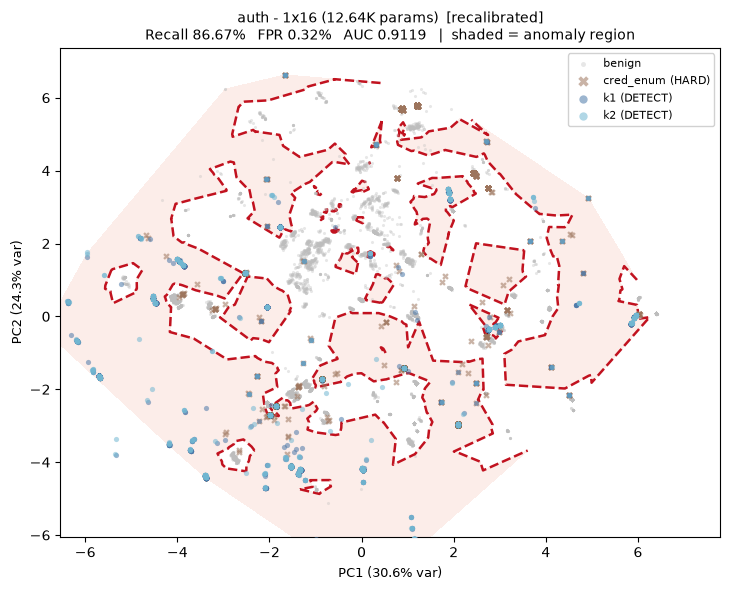

[post] threshold=-29.2779  score range=[-127.765, 10.7185]


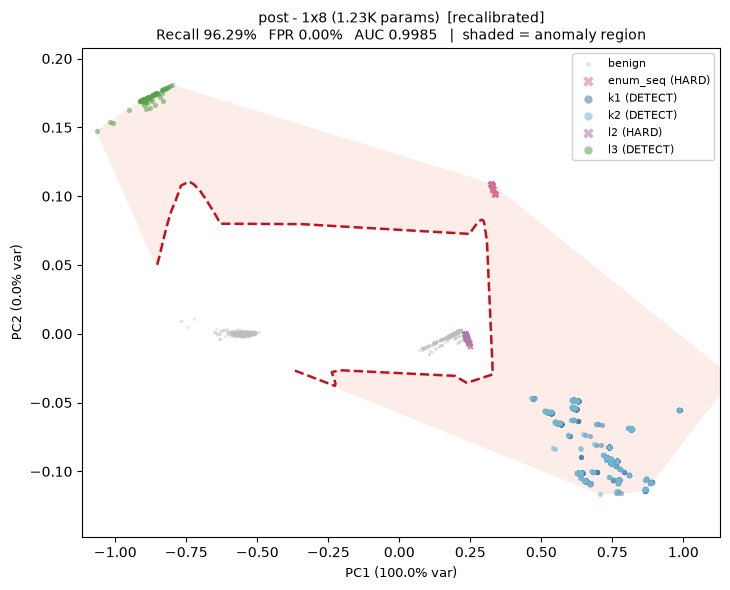

[comment] threshold=-0.269468  score range=[-0.269471, 0.0991274]


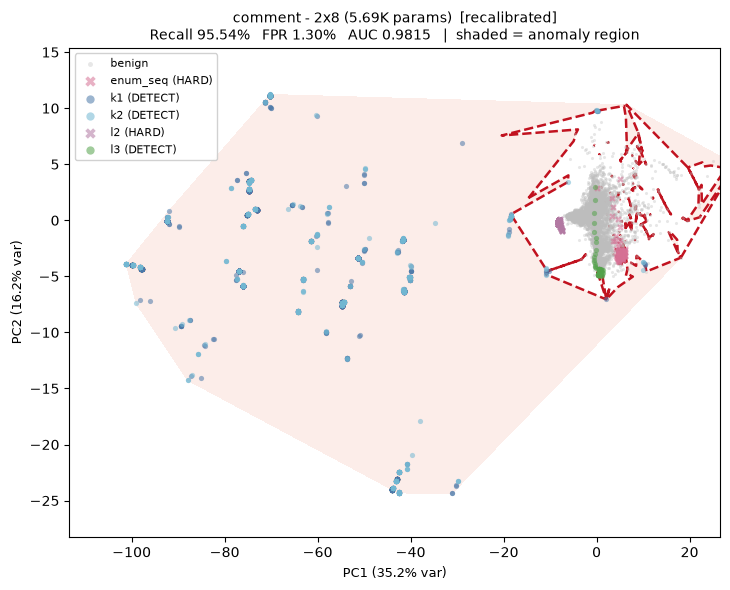

[frontend] threshold=-114.404  score range=[-566.608, 91.8809]


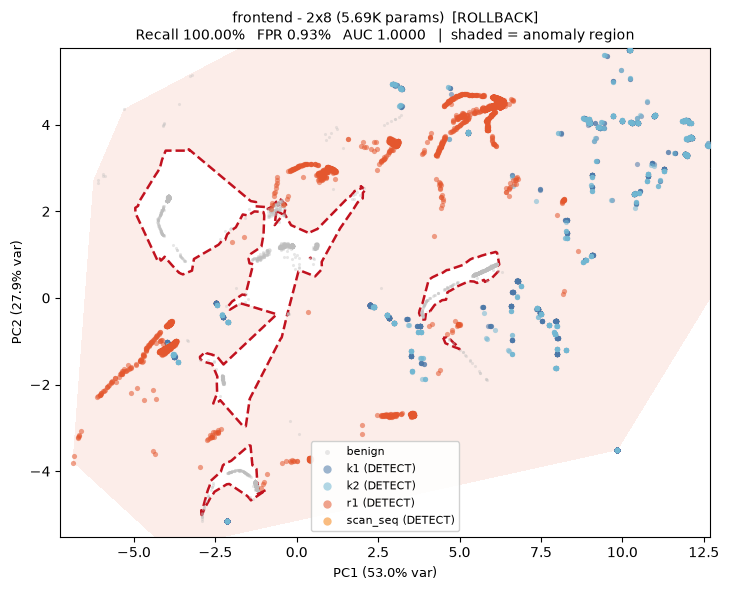

In [19]:
BENIGN_CAP = 6000
ATTACK_CAP = 6000
rng = np.random.default_rng(42)

for svc in SERVICES:
    model_name = FINAL_MODELS[svc]
    X_benign, X_attack, scen_slices, _meta = build_service_dataset(svc)
    det = EvalDetector(model_name, svc, device=DEVICE)

    Zb, Za = embed_many(det, X_benign), embed_many(det, X_attack)
    sb = det.ocsvm.decision_function(Zb)
    sa = det.ocsvm.decision_function(Za)
    m = metrics_from_scores(sb, sa, det.threshold)

    pca = PCA(n_components=2).fit(Zb)
    Pb_all, Pa_all = pca.transform(Zb), pca.transform(Za)

    fig, ax = plt.subplots(figsize=(7.4, 6.0))

    # 정상·공격 표본의 점수로 경계 추정
    P_all = np.vstack([Pb_all, Pa_all])
    s_all = np.r_[sb, sa]
    print(f"[{svc}] threshold={det.threshold:.6g}  "
          f"score range=[{s_all.min():.6g}, {s_all.max():.6g}]")
    drew = draw_empirical_boundary(ax, P_all, s_all, det.threshold, rng=rng)

    Pb, _ = _subsample(Pb_all, BENIGN_CAP, rng)
    ax.scatter(Pb[:, 0], Pb[:, 1], s=5, c="#bdbdbd", alpha=0.35,
               linewidths=0, label="benign", zorder=2)

    for scen, sl in scen_slices.items():
        blk = Pa_all[sl]
        if len(blk) == 0:
            continue
        blk, _ = _subsample(blk, ATTACK_CAP, rng)
        grade = SCEN_GRADE.get(scen, "HARD")
        ax.scatter(blk[:, 0], blk[:, 1],
                   s=14 if grade == "DETECT" else 22,
                   c=SCEN_COLOR.get(scen, "#000000"),
                   marker="o" if grade == "DETECT" else "X",
                   alpha=0.55, linewidths=0, zorder=3,
                   label=f"{scen} ({grade})")

    # 이상치 영향을 줄이도록 축 범위를 분위수로 설정
    lo, hi = np.percentile(P_all, 0.5, axis=0), np.percentile(P_all, 99.5, axis=0)
    pad = 0.12 * np.maximum(hi - lo, 1e-9)
    ax.set_xlim(lo[0] - pad[0], hi[0] + pad[0])
    ax.set_ylim(lo[1] - pad[1], hi[1] + pad[1])

    ax.set_xlabel(f"PC1 ({pca.explained_variance_ratio_[0]*100:.1f}% var)", fontsize=9)
    ax.set_ylabel(f"PC2 ({pca.explained_variance_ratio_[1]*100:.1f}% var)", fontsize=9)
    bnote = "shaded = anomaly region" if drew else "boundary not in view"
    ax.set_title(
        f"{svc} - {model_name} ({det.params/1000:.2f}K params)  "
        f"[{'recalibrated' if det.recalibrated else 'ROLLBACK'}]\n"
        f"Recall {m['recall']*100:.2f}%   FPR {m['fpr']*100:.2f}%   "
        f"AUC {m['auc']:.4f}   |  {bnote}",
        fontsize=10)
    ax.legend(markerscale=1.6, fontsize=8, loc="best", framealpha=0.9)
    fig.tight_layout()
    fig.savefig(FIG_DIR / f"pca_boundary_{svc}_{model_name}.png", dpi=170)
    plt.show()

    del det, Zb, Za, X_benign, X_attack
    gc.collect()

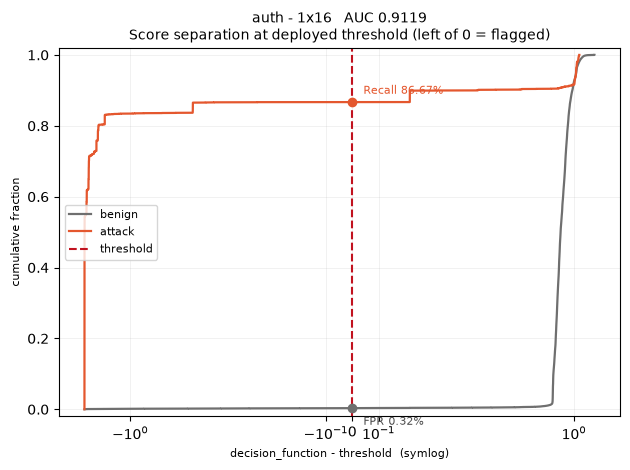

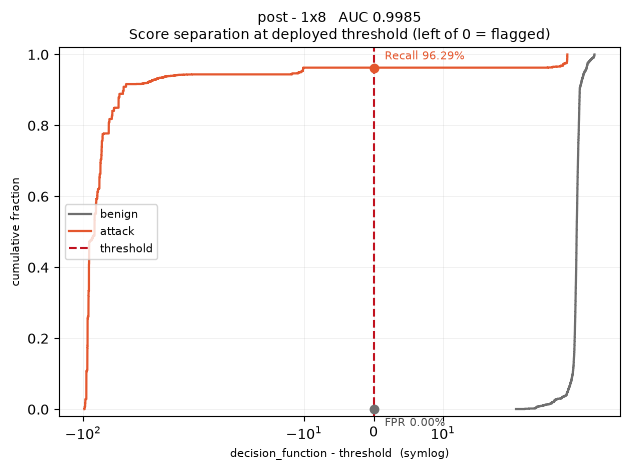

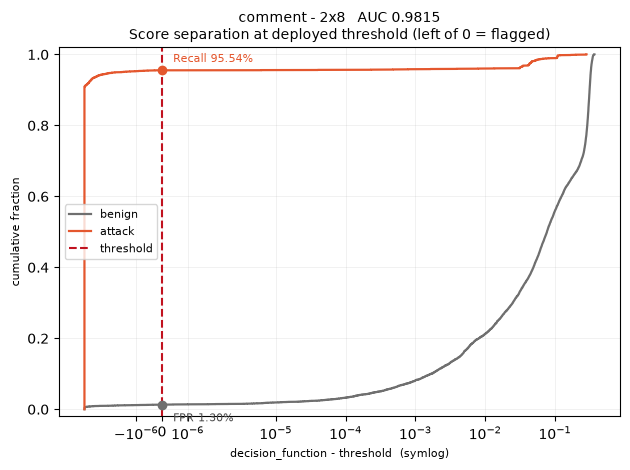

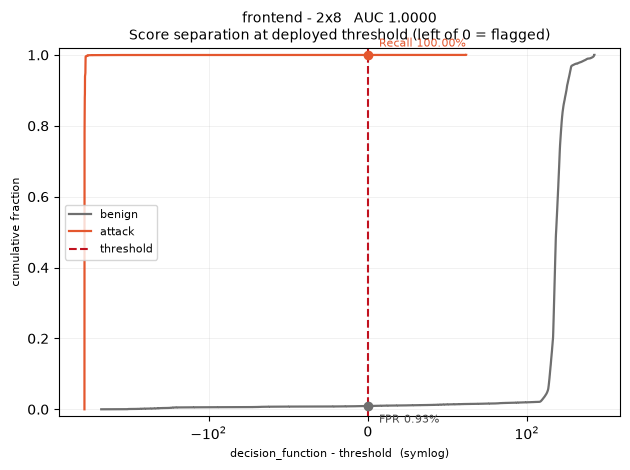

In [24]:
for svc in SERVICES:
    model_name = FINAL_MODELS[svc]
    X_benign, X_attack, _sl, _meta = build_service_dataset(svc)
    det = EvalDetector(model_name, svc, device=DEVICE)

    sb = det.ocsvm.decision_function(embed_many(det, X_benign))
    sa = det.ocsvm.decision_function(embed_many(det, X_attack))
    m = metrics_from_scores(sb, sa, det.threshold)

    db = np.sort(sb - det.threshold)          # 0보다 작으면 이상
    da = np.sort(sa - det.threshold)
    eb = np.arange(1, len(db) + 1) / len(db)
    ea = np.arange(1, len(da) + 1) / len(da)

    fig, ax = plt.subplots(figsize=(6.4, 4.8))

    nz = np.abs(np.r_[db, da])
    nz = nz[nz > 0]
    lt = float(np.percentile(nz, 5)) if len(nz) else 1e-9
    ax.set_xscale("symlog", linthresh=max(lt, 1e-12))

    ax.step(db, eb, where="post", color="#6f6f6f", lw=1.6, label="benign")
    ax.step(da, ea, where="post", color="#e4572e", lw=1.6, label="attack")
    ax.axvline(0.0, color="#c1121f", ls="--", lw=1.5, label="threshold")

    ax.plot([0], [m["fpr"]], "o", color="#6f6f6f", ms=6, zorder=5)
    ax.plot([0], [m["recall"]], "o", color="#e4572e", ms=6, zorder=5)
    ax.annotate(f"FPR {m['fpr']*100:.2f}%", (0, m["fpr"]),
                textcoords="offset points", xytext=(8, -12), fontsize=8, color="#4a4a4a")
    ax.annotate(f"Recall {m['recall']*100:.2f}%", (0, m["recall"]),
                textcoords="offset points", xytext=(8, 6), fontsize=8, color="#e4572e")

    ax.set_ylim(-0.02, 1.02)
    ax.set_title(f"{svc} - {model_name}   AUC {m['auc']:.4f}\n"
                 f"Score separation at deployed threshold (left of 0 = flagged)",
                 fontsize=10)
    ax.set_xlabel("decision_function - threshold  (symlog)", fontsize=8)
    ax.set_ylabel("cumulative fraction", fontsize=8)
    ax.grid(alpha=0.25, lw=0.5)
    ax.legend(fontsize=8, loc="center left")

    fig.tight_layout()
    fig.savefig(FIG_DIR / f"score_ecdf_{svc}_{model_name}.png", dpi=170)
    plt.show()

    del det, X_benign, X_attack
    gc.collect()

In [22]:
import matplotlib.pyplot as plt
import numpy as np

FIG_DIR = ROOT / "figs_latency"
FIG_DIR.mkdir(exist_ok=True)

# 서비스별 확정 모델
FINAL_MODELS = {"auth": "1x16", "post": "1x8", "comment": "2x8", "frontend": "2x8"}

_lat = pd.DataFrame(SERVICE_ROWS)

def latency_frame(svc):
    """서비스별 측정값을 MODEL_ORDER 순서로 반환한다."""
    d = _lat[_lat["Service"] == svc].copy()
    d["__o"] = d["Model"].map({m: i for i, m in enumerate(MODEL_ORDER)})
    d = d.sort_values("__o").drop(columns="__o")

    # 같은 의미의 열 이름 지원
    def pick(*cands):
        for c in cands:
            if c in d.columns:
                return c
        raise KeyError(f"열을 찾을 수 없음: {cands} / 실제: {list(d.columns)}")

    return (d["Model"].tolist(),
            d[pick("Params (K)", "Params(K)", "Params")].to_numpy(float),
            d[pick("Encoder ms/img", "Encoder(ms/img)")].to_numpy(float),
            d[pick("Detector ms/img", "Detector(ms/img)")].to_numpy(float),
            d[pick("Recalibration", "재보정")].tolist())

for svc in SERVICES:
    ms, pk, enc, det, rc = latency_frame(svc)
    print(f"{svc:9s}", " ".join(f"{m}:{v:.4f}" for m, v in zip(ms, det)))

auth      teacher:0.6848 1x8:0.4895 2x8:0.4972 1x16:0.3831 2x16:0.4408 2x32:0.5055
post      teacher:0.6706 1x8:0.3615 2x8:0.6112 1x16:0.3642 2x16:0.4419 2x32:0.5233
comment   teacher:0.6768 1x8:0.5062 2x8:1.1294 1x16:0.5148 2x16:0.9066 2x32:0.6108
frontend  teacher:0.7131 1x8:0.7461 2x8:0.8049 1x16:0.5468 2x16:0.6235 2x32:0.8531


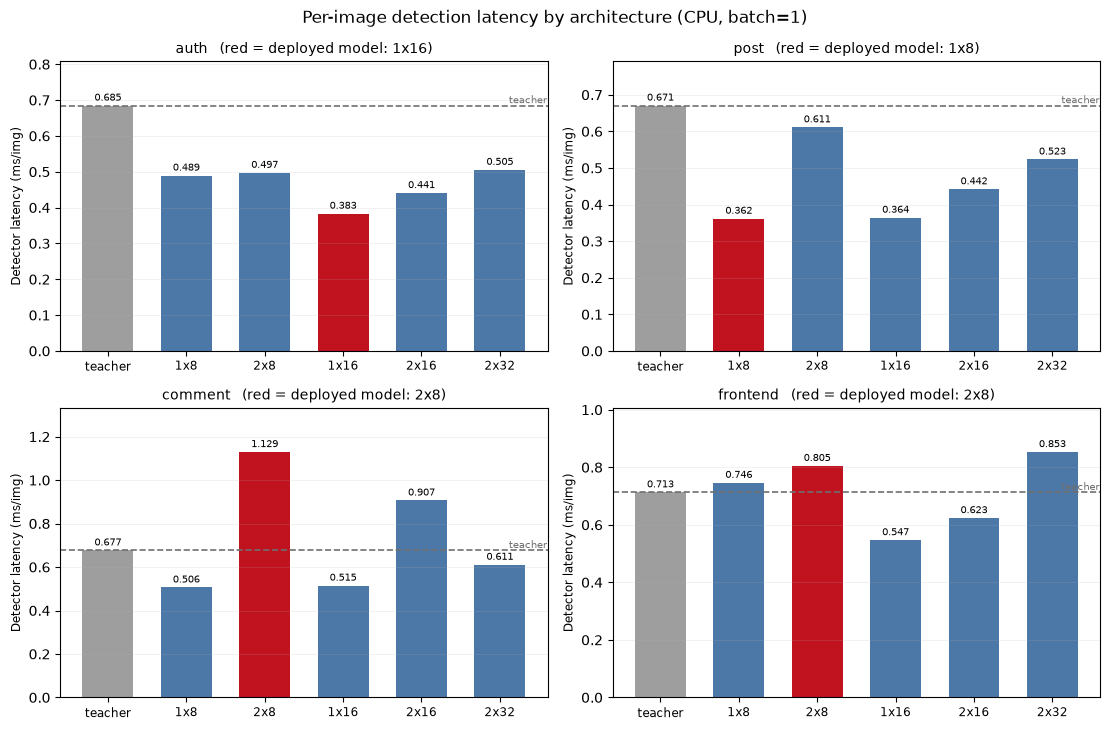

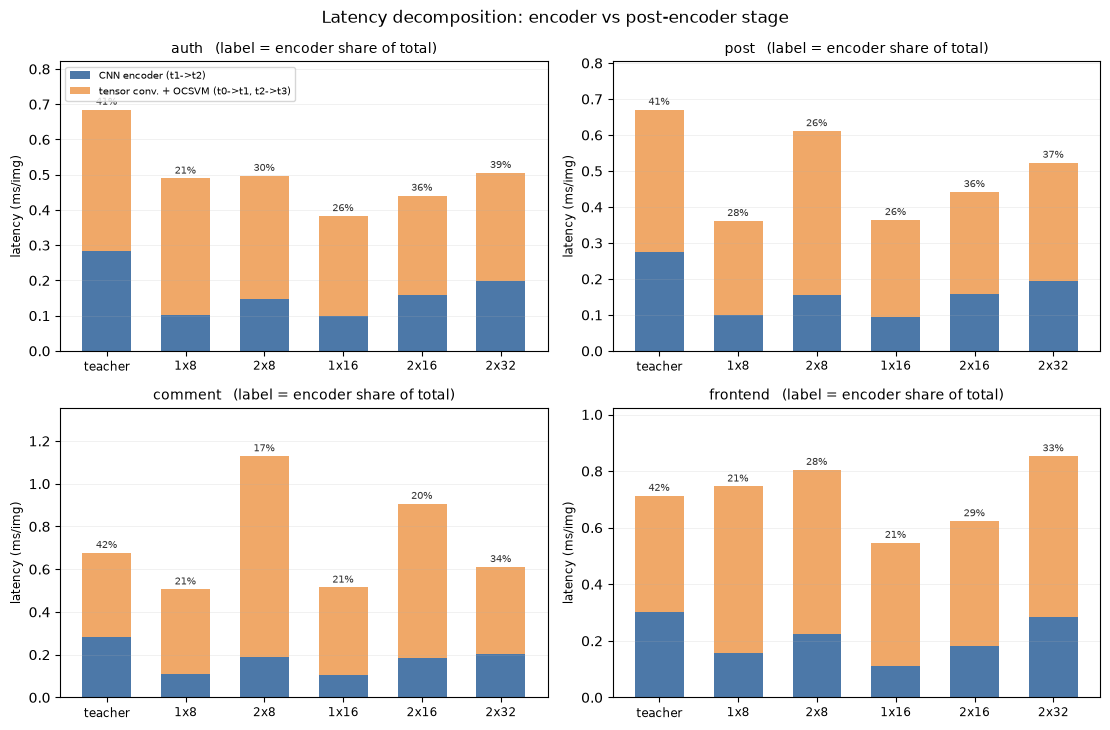

In [23]:
# 서비스별 모델 추론시간
fig, axes = plt.subplots(2, 2, figsize=(11.2, 7.4))
for ax, svc in zip(axes.ravel(), SERVICES):
    models, params, enc, det, recal = latency_frame(svc)
    colors = ["#9e9e9e" if m == "teacher"
              else "#c1121f" if m == FINAL_MODELS[svc]
              else "#4c78a8" for m in models]
    bars = ax.bar(range(len(models)), det, color=colors, width=0.65)

    if "teacher" in models:
        t = det[models.index("teacher")]
        ax.axhline(t, color="#6f6f6f", ls="--", lw=1.2)
        ax.text(len(models) - 0.4, t, "teacher", fontsize=7,
                color="#6f6f6f", va="bottom", ha="right")

    for b, v in zip(bars, det):
        ax.text(b.get_x() + b.get_width() / 2, v + max(det) * 0.02,
                f"{v:.3f}", ha="center", fontsize=7.5)

    ax.set_ylim(0, max(det) * 1.18)
    ax.set_xticks(range(len(models)))
    ax.set_xticklabels(models, fontsize=8.5)
    ax.set_ylabel("Detector latency (ms/img)", fontsize=8.5)
    ax.set_title(f"{svc}   (red = deployed model: {FINAL_MODELS[svc]})", fontsize=10)
    ax.grid(axis="y", alpha=0.25, lw=0.5)

fig.suptitle("Per-image detection latency by architecture (CPU, batch=1)", fontsize=12)
fig.tight_layout()
fig.savefig(FIG_DIR / "fig_latency_by_service.png", dpi=170)
plt.show()

# Encoder와 나머지 처리 시간
fig, axes = plt.subplots(2, 2, figsize=(11.2, 7.4))
for ax, svc in zip(axes.ravel(), SERVICES):
    models, params, enc, det, recal = latency_frame(svc)
    rest = det - enc
    x = np.arange(len(models))

    ax.bar(x, enc, width=0.62, color="#4c78a8", label="CNN encoder (t1->t2)")
    ax.bar(x, rest, width=0.62, bottom=enc, color="#f0a868",
           label="tensor conv. + OCSVM (t0->t1, t2->t3)")

    for i in range(len(models)):
        ax.text(x[i], det[i] + max(det) * 0.02, f"{enc[i] / det[i] * 100:.0f}%",
                ha="center", fontsize=7.5, color="#333333")

    ax.set_ylim(0, max(det) * 1.20)
    ax.set_xticks(x)
    ax.set_xticklabels(models, fontsize=8.5)
    ax.set_ylabel("latency (ms/img)", fontsize=8.5)
    ax.set_title(f"{svc}   (label = encoder share of total)", fontsize=10)
    ax.grid(axis="y", alpha=0.25, lw=0.5)
    if svc == SERVICES[0]:
        ax.legend(fontsize=7.5, loc="upper left")

fig.suptitle("Latency decomposition: encoder vs post-encoder stage", fontsize=12)
fig.tight_layout()
fig.savefig(FIG_DIR / "fig_latency_breakdown.png", dpi=170)
plt.show()